IMPORTING LIBRARIES

In [1]:
# IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
plt.style.use("ggplot")

LOADING THE DATASET

In [3]:
# LOAD DATASET 
file_path = "C:/Users/PC/Desktop/kaggle_survey_2017_2021.csv" 

raw = pd.read_csv("C:/Users/PC/Desktop/kaggle_survey_2017_2021.csv", low_memory=False)

print("Raw Shape:", raw.shape)
raw.head()
raw.columns


Raw Shape: (106302, 293)


Index(['-', 'Time from Start to Finish (seconds)', 'Q1', 'Q2', 'Q3', 'Q4',
       'Q5', 'Q6', 'Q7_Part_1', 'Q7_Part_2',
       ...
       'Q38_B_Part_1', 'Q38_B_Part_2', 'Q38_B_Part_3', 'Q38_B_Part_4',
       'Q38_B_Part_5', 'Q38_B_Part_6', 'Q38_B_Part_7', 'Q38_B_Part_9',
       'Q38_B_Part_11', 'Q38_B_OTHER'],
      dtype='object', length=293)

EXPLANATION : This shows the top first five rows of the data including columns such as 

**Identifier and Timing:**
- Year — the survey year
- Time from Start to Finish (seconds) — how long each respondent took to complete

**Demographics (Q1-Q4):**
- Q1 — asking about age in years
- Q2 — asking about gender
- Q3 — asking which country the respondent currently resides in
- Q4 — asking about the highest level of formal education completed

**Professional Background (Q5-Q6):**
- Q5 — asking to select the job title most similar to their current role
- Q6 — asking for how many years they have been writing code

**Programming Languages (Q7 series):**
- Q7_Part_1 — what programming languages they use on a regular basis
- Q7_Part_2 — additional programming language option
- The pattern continues with ellipsis indicating more Q7 parts follow

**Future Learning Interests (Q38_B series from second image):**
- Q38_B_Part_1 through Q38_B_Part_11 — asking what technologies they hope to become more familiar with in the next 2 years
- Q38_B_Part_4 specifically shows "TensorBoard" as one option
- Q38_B_OTHER — a catch-all for write-in responses not covered by the predefined parts

The dataset contains **293 total columns and 106,302 rows** 

REMOVING FIRST ROW 

In [6]:
# FIX: FIRST ROW IS QUESTION TEXT (NOT RESPONSES)
# row 1 contains the question text (metadata)
question_row = raw.iloc[0].copy()

# actual survey responses start from row 2
df = raw.iloc[1:].copy()

print("Responses shape:", df.shape)
df.head()

Responses shape: (106301, 293)


,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q38_B_Part_1,Q38_B_Part_2,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_9,Q38_B_Part_11,Q38_B_OTHER
1,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,784,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,924,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN
4,2021,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2021,781,45-49,Man,India,Doctoral degree,Other,< 1 years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Explanation : The first row of the Kaggle survey dataset contains the full question text, not actual survey responses. If i keep this row, it can cause errors when converting columns to numeric values and can distort summary statistics and analysis results.
By removing it, I ensured that the dataset only contains real respondent data, allowing for accurate cleaning, encoding, and analysis.

Renaming Columns and Converting Types

In [9]:
# RENAME KEY COLUMNS and TYPE FIXING


df = df.rename(columns={
    "-": "Year",
    "Time from Start to Finish (seconds)": "Duration_seconds"
})

# Convert numeric columns
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
if "Duration_seconds" in df.columns:
    df["Duration_seconds"] = pd.to_numeric(df["Duration_seconds"], errors="coerce")

df[["Year", "Duration_seconds"]].head()

,Year,Duration_seconds
1,2021,910.0
2,2021,784.0
3,2021,924.0
4,2021,575.0
5,2021,781.0


Explanation: I renamed the columns to make them clearer and easier to understand.  changing symbols like “-” to “Year” improves readability and makes the dataset more meaningful when analyzing or writing code.
I converted data types (such as Year or Duration) to numeric format so that we can perform calculations, summaries, and statistical analysis correctly. If these columns remain as text, i cannot compute averages, trends, or correlations properly.
Renaming improves clarity, and converting data types ensures accurate analysis.

CHECKING MISSING VALUES AND DUPLICATES

In [12]:
# CHECKING DATA QUALITY
print("Total Missing Values Per Column (Top 10):")
display(df.isna().sum().sort_values(ascending=False).head(10))
print("Duplicate Rows:", df.duplicated().sum())

Total Missing Values Per Column (Top 10):


Q16_Part_17      106301
Q34_B_Part_16    106301
Q9_Part_12       106301
Q34_A_Part_16    106301
Q32_A_Part_20    106301
Q14_Part_11      106301
Q27_B_Part_11    106301
Q10_Part_16      106301
Q19_Part_5       106301
Q32_B_Part_20    106301
dtype: int64

Duplicate Rows: 4456


Explanation: The output shows the number of missing values in each column of the dataset. The columns listed (such as Q16_Part_17, Q34_B_Part_16, etc.) each contain 106,301 missing values. This means that most respondents did not provide answers for these specific questions. These columns are likely multi-select questions (for example, tools or technologies used), where each option is stored in a separate column. If a respondent did not select a particular option, it appears as a missing value. Therefore, a high number of missing values in these columns is expected and does not necessarily indicate an error.
The output also shows that there are 4,456 duplicate rows in the dataset. This means some responses appear more than once and should be removed to prevent bias or inaccurate analysis.
 This step helps us understand the completeness of the data and identify areas that require cleaning before analysis.

REMOVING DUPLICATES

In [15]:
# REMOVE DUPLICATE RESPONSES

print("Duplicate rows before removal:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after removal:", df.duplicated().sum())
print("New dataset shape:", df.shape)

Duplicate rows before removal: 4456
Duplicate rows after removal: 0
New dataset shape: (101845, 293)


Explanation: Because the dataset contained 4,456 duplicate rows, they were removed to prevent bias and ensure accurate analysis. The large number of missing values in multi-select columns is expected so i left it the way it is.

CLEANING TEXT COLUMNS

In [18]:
# CLEAN TEXT COLUMNS
# Remove extra spaces
text_cols = df.select_dtypes(include="object").columns
df[text_cols] = df[text_cols].apply(lambda x: x.str.strip())
# Replace empty strings with NaN
df[text_cols] = df[text_cols].replace("", np.nan)
print("Cleaned Shape:", df.shape)

Cleaned Shape: (101845, 293)


Explanation: Rows that had extra spaces  and empty strings were removed

SELECTING IMPORTANT COLUMNS

In [21]:
# SELECT IMPORTANT SURVEY COLUMNS
COL_AGE = "Q1"
COL_GENDER = "Q2"
COL_COUNTRY = "Q3"
COL_EDU = "Q4"
COL_ROLE = "Q5"
COL_CODING_EXP = "Q6"
COL_COMP = "Q25"
important_cols = [c for c in [COL_AGE, COL_GENDER, COL_COUNTRY,
                              COL_EDU, COL_ROLE, COL_CODING_EXP, COL_COMP]
                  if c in df.columns]
sub = df[important_cols].copy()

sub.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q25
1,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,"25,000-29,999"
2,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,"60,000-69,999"
3,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,$0-999
4,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,"30,000-39,999"
5,45-49,Man,India,Doctoral degree,Other,< 1 years,"30,000-39,999"


Explanation:In this step, I selected only the key columns needed for our analysis. The Kaggle survey dataset contains many columns, including multiple multi-select questions, which can make analysis complex and unnecessary for our objectives. Therefore, I focused on important variables such as age (Q1), gender (Q2), country (Q3), education level (Q4), job role (Q5), coding experience (Q6), and compensation (Q25).
I created a list of these column names and then filtered the dataset to keep only those that actually exist in the dataframe. The condition if c in df.columns ensures that the code does not break if a specific column is missing in a particular survey year. This makes the code safer and more flexible.
Regarding Q25 (Compensation), it may not be immediately visible when first loading the dataset because the Kaggle survey includes many columns, and some may not appear in the initial preview. Additionally, since the first row originally contained question text, column structure can look confusing before cleaning. However, Q25 does exist in the dataset as the column representing yearly compensation, and it becomes usable once the dataset is properly cleaned and structured. it can also be viewed directly in excel.

HANDLING NON-RESPONSES

In [24]:
# CLEAN NON-RESPONSES

def clean_nonanswers(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower()
    if "prefer not" in s or "do not wish" in s:
        return np.nan
    return x

for col in important_cols:
    sub[col] = sub[col].apply(clean_nonanswers)

# Fill key categoricals
for col in [COL_GENDER, COL_COUNTRY, COL_EDU, COL_ROLE]:
    if col in sub.columns:
        sub[col] = sub[col].fillna("Unknown")

sub.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q25
1,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,"25,000-29,999"
2,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,"60,000-69,999"
3,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,$0-999
4,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,"30,000-39,999"
5,45-49,Man,India,Doctoral degree,Other,< 1 years,"30,000-39,999"


Explanation: I  handled responses such as “Prefer not to answer” because they do not contain actual information about the respondent. These responses indicate that the participant chose not to provide data, rather than providing a meaningful category like a specific age group, country, or salary range.If these responses remain unchanged, they would be treated as valid categories during analysis. This could distort distributions, percentages, and encoded values, and potentially bias the results. For example, when calculating gender distribution or average salary by education level, “Prefer not to answer” would incorrectly appear as a real group.
By converting these responses to missing values, we ensure that only meaningful and informative data is used in analysis. This improves the accuracy, clarity, and reliability of our results

ENCODING CATEGORICAL VARIABLES

In [27]:
# LABEL ENCODING# 

le = LabelEncoder()

if COL_GENDER in sub.columns:
    sub["Gender_encoded"] = le.fit_transform(sub[COL_GENDER].astype(str))

if COL_COUNTRY in sub.columns:
    sub["Country_encoded"] = le.fit_transform(sub[COL_COUNTRY].astype(str))

if COL_ROLE in sub.columns:
    sub["Role_encoded"] = le.fit_transform(sub[COL_ROLE].astype(str))

sub.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q25,Gender_encoded,Country_encoded,Role_encoded
1,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,"25,000-29,999",3,25,19
2,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,"60,000-69,999",3,26,24
3,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,$0-999,3,45,32
4,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,"30,000-39,999",3,37,27
5,45-49,Man,India,Doctoral degree,Other,< 1 years,"30,000-39,999",3,25,19


Explanation: In this step, i applied label encoding to categorical variables such as Gender (Q2), Country (Q3), and Role (Q5). Label encoding converts text categories into numerical values so that they can be used in mathematical analysis or machine learning models.In the output, new columns were created: Gender_encoded, Country_encoded, and Role_encoded. These columns contain numeric representations of the original text values. For example, “Man” may be encoded as 3, “India” may be encoded as 25, and a role like “Software Engineer” may be encoded as 32. These numbers do not represent rankings or importance; they are simply unique identifiers assigned to each category.
This transformation allows the dataset to remain machine-readable while preserving the original categorical information. The original columns (Q2, Q3, Q5) are still kept for interpretation, while the encoded columns are useful for modeling, correlation analysis, or further statistical computation.

In [38]:
# VIEW ENCODING MAPPINGS


print("Gender Mapping:")
display(
    sub[[COL_GENDER, "Gender_encoded"]]
    .drop_duplicates()
    .sort_values("Gender_encoded")
)

print("Country Mapping:")
display(
    sub[[COL_COUNTRY, "Country_encoded"]]
    .drop_duplicates()
    .sort_values("Country_encoded")
)

print("Role Mapping:")
display(
    sub[[COL_ROLE, "Role_encoded"]]
    .drop_duplicates()
    .sort_values("Role_encoded")
)

Gender Mapping:


,Q2,Gender_encoded
89715,A different identity,0
46012,Female,1
46010,Male,2
1,Man,3
89586,"Non-binary, genderqueer, or gender non-conforming",4
33,Nonbinary,5
450,Prefer to self-describe,6
67,Unknown,7
6,Woman,8


Country Mapping:


,Q3,Country_encoded
85,Algeria,0
91,Argentina,1
11,Australia,2
168,Austria,3
56,Bangladesh,4
...,...,...
89587,United States,72
33,United States of America,73
104,Unknown,74
44,Viet Nam,75


Role Mapping:


,Q5,Role_encoded
54,Business Analyst,0
65747,Chief Officer,1
89590,Computer Scientist,2
65727,Consultant,3
6,Currently not employed,4
371,DBA/Database Engineer,5
17,Data Analyst,6
66,Data Engineer,7
67531,Data Journalist,8
89786,Data Miner,9


Explanation: This table gives the mapping for the encoded values

    CONVERTING COMPENSATION TO NUMERIC

In [45]:
# CONVERT COMPENSATION TO NUMERIC
def convert_comp(x):
    if pd.isna(x):
        return np.nan
    
    s = str(x).replace("$", "").replace(",", "").strip()
    
    # Handle 500000+
    plus = re.match(r"^(\d+)\+$", s)
    if plus:
        return float(plus.group(1))
    
    # Handle 10000-19999
    rng = re.match(r"^(\d+)-(\d+)$", s)
    if rng:
        return (float(rng.group(1)) + float(rng.group(2))) / 2
    
    return np.nan

if COL_COMP in sub.columns:
    sub["Comp_numeric"] = sub[COL_COMP].apply(convert_comp)

sub.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q25,Gender_encoded,Country_encoded,Role_encoded,Comp_numeric
1,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,"25,000-29,999",3,25,19,27499.5
2,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,"60,000-69,999",3,26,24,64999.5
3,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,$0-999,3,45,32,499.5
4,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,"30,000-39,999",3,37,27,34999.5
5,45-49,Man,India,Doctoral degree,Other,< 1 years,"30,000-39,999",3,25,19,34999.5


Explanation:To make the data usable for analysis, i converted  these ranges into a single numeric value by taking the midpoint of each range. For example, the range 10,000–19,999 is converted to approximately 14,999.5. This allows me to treat compensation as a continuous numeric variable.
Converting compensation to numeric values enables me  to perform calculations such as averages, comparisons between job roles, correlations with experience, and visualizations like salary distributions. Without this conversion, statistical analysis and meaningful insights about earnings would not be possible.

TOP 5 VISUALIZATIONS AND INSIGHTS

Q3
India                                                   23936
United States of America                                12682
Other                                                    5532
China                                                    3502
Russia                                                   3299
Brazil                                                   3283
Japan                                                    3070
Germany                                                  2521
United States                                            2509
United Kingdom of Great Britain and Northern Ireland     2223
Name: count, dtype: int64

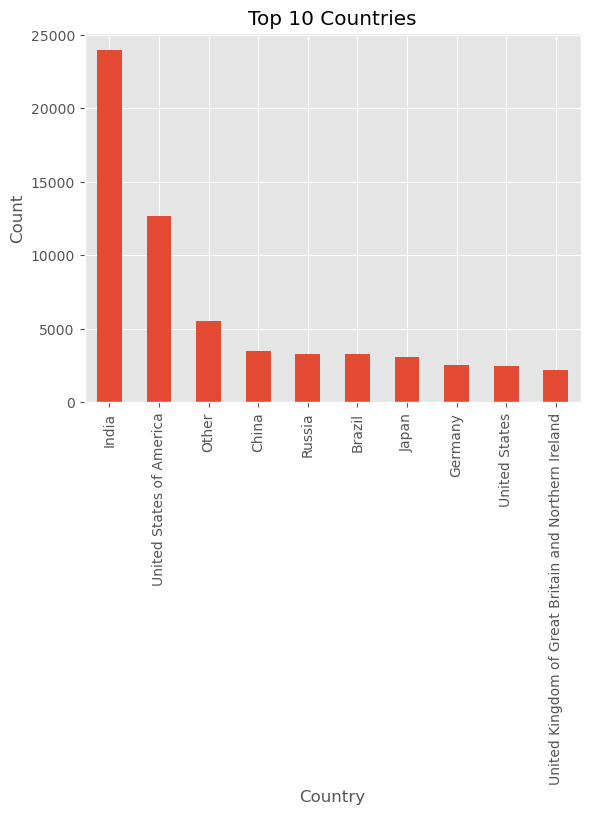

In [55]:
# INSIGHT 1: TOP COUNTRIES IN THE SURVEY

if COL_COUNTRY in sub.columns:
    top_countries = sub[COL_COUNTRY].value_counts().head(10)
    display(top_countries)
    
    top_countries.plot(kind="bar")
    plt.title("Top 10 Countries")
    plt.xlabel("Country")
    plt.ylabel("Count")
    plt.show()

Explanation:The bar chart shows the top 10 countries with the highest number of respondents in the survey. The counts represent the frequency of participants from each country.
Statistically, India has the highest representation, followed by the United States of America, indicating that a large proportion of the survey data comes from these two countries. Other countries such as China, Russia, Brazil, Japan, Germany, and the United Kingdom contribute smaller but notable portions of the dataset.

Q2
Male                                                 44.40
Man                                                  35.71
Female                                                9.39
Woman                                                 8.61
Unknown                                               1.31
Prefer to self-describe                               0.22
A different identity                                  0.15
Nonbinary                                             0.14
Non-binary, genderqueer, or gender non-conforming     0.07
Name: proportion, dtype: float64

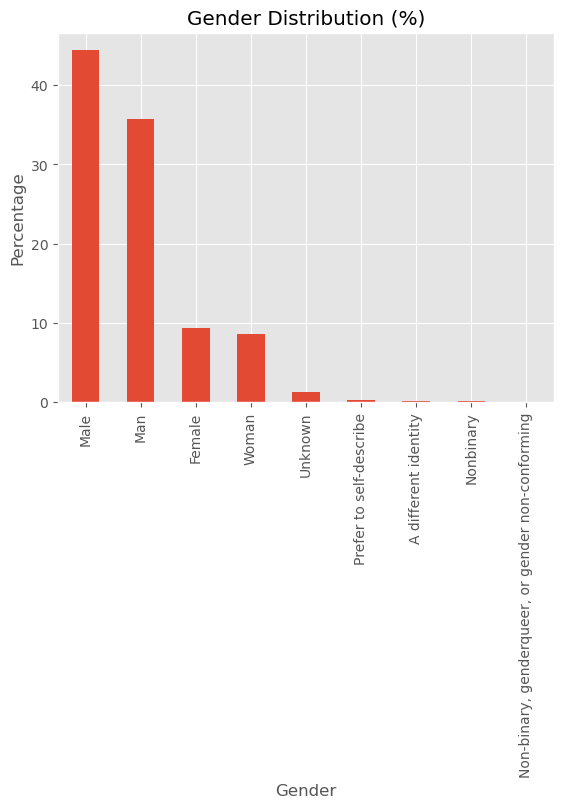

In [57]:
# INSIGHT 2: GENDER DISTRIBUTION

if COL_GENDER in sub.columns:
    gender_percent = (sub[COL_GENDER].value_counts(normalize=True) * 100).round(2)
    display(gender_percent)
    
    gender_percent.plot(kind="bar")
    plt.title("Gender Distribution (%)")
    plt.xlabel("Gender")
    plt.ylabel("Percentage")
    plt.show()

Explanation:The bar chart presents the percentage distribution of respondents by gender in the dataset. The results show that male respondents dominate the survey, with “Male” and “Man” categories together accounting for the majority of participants. In contrast, female respondents (“Female” and “Woman”) represent a much smaller proportion, while other gender identities and unspecified responses account for a very small percentage. This indicates a strong gender imbalance in the survey, with male participants significantly overrepresented.This imbalance suggests that insights derived from the survey may largely reflect the perspectives and experiences of male respondents, highlighting the ongoing gender gap within the data science and technology fields.

Q5
Chief Officer                   84029.96
Product Manager                 74194.73
Principal Investigator          64650.33
Product/Project Manager         57814.65
Program/Project Manager         55581.45
Manager                         53435.96
Data Scientist                  49118.27
Other                           45830.42
Developer Relations/Advocacy    44422.12
Data Engineer                   41905.47
Name: Comp_numeric, dtype: float64

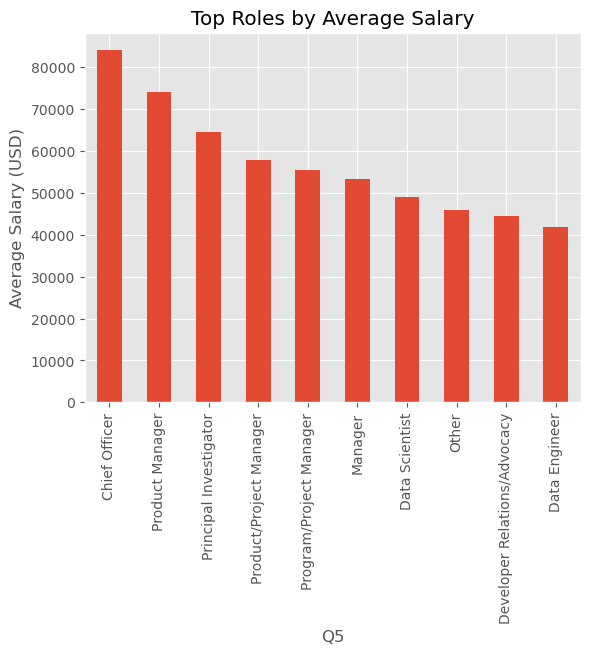

In [61]:
# INSIGHT 3: AVG SALARY BY ROLE
if COL_ROLE in sub.columns and "Comp_numeric" in sub.columns:
    avg_salary = (
        sub.dropna(subset=["Comp_numeric"])
           .groupby(COL_ROLE)["Comp_numeric"]
           .mean()
           .sort_values(ascending=False)
           .head(10)
    )
    
    display(avg_salary.round(2))
    
    avg_salary.plot(kind="bar")
    plt.title("Top Roles by Average Salary")
    plt.ylabel("Average Salary (USD)")
    plt.show()

Explanation:The table and bar chart display the average compensation (USD) by job role based on the survey responses. The values were calculated by converting salary ranges into numeric midpoints and then computing the mean salary for each role.Statistically, Chief Officers report the highest average salary (≈ 84,030), followed  by product managers (≈ 74,195) and Principal Investigators (≈ 64,650). Technical roles such as Data Scientists (≈ 49,118) and Data Engineers (≈ 41,905) appear lower in the ranking. This pattern suggests that executive and management positions tend to command higher average salaries than technical specialist roles, likely reflecting greater leadership responsibility and organizational decision-making authority.

Python                   65942
SQL                      33090
R                        20884
Java                     14402
C++                      11618
C                         9696
Javascript                9501
MATLAB                    9320
Bash                      8737
Javascript/Typescript     3249
Name: count, dtype: int64

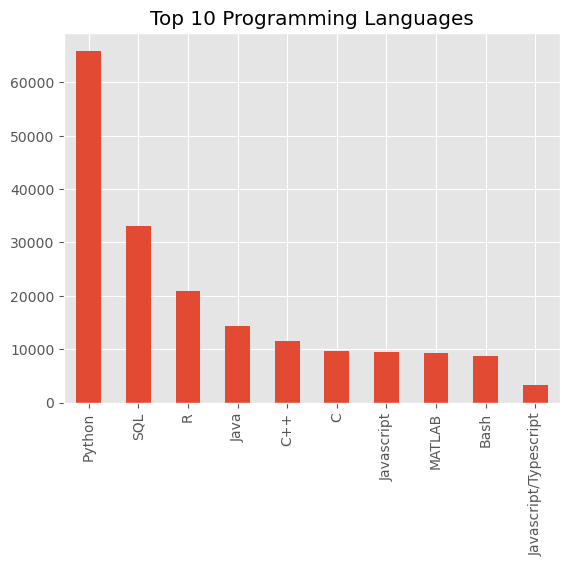

In [67]:
# INSIGHT 4: TOP PROGRAMMING LANGUAGES
lang_cols = [c for c in df.columns if c.startswith("Q7_Part_")]

if len(lang_cols) > 0:
    languages = (
        df[lang_cols]
        .stack()
        .dropna()
        .astype(str)
        .str.strip()
    )
    
    top_languages = languages.value_counts().head(10)
    display(top_languages)
    
    top_languages.plot(kind="bar")
    plt.title("Top 10 Programming Languages")
    plt.show()
else:
    print("No Q7 multi-select columns found.")

Explain:The bar chart displays the top 10 programming languages used by survey respondents, based on the frequency of selections in the dataset. Statistically, Python is the most commonly used language, with a substantially higher count compared to other languages. SQL and R follow as the second and third most frequently used languages. Other languages such as Java, C++, C, JavaScript, MATLAB, Bash, and TypeScript, appear with lower but notable usage levels.The dominance of Python and SQL reflects their central role in data science workflows, particularly for data analysis, machine learning, and database querying. The presence of languages like R and MATLAB suggests continued use in statistical analysis and research-oriented environments.

Languages per respondent (summary):
count    101845.000000
mean          1.842761
std           1.623368
min           0.000000
25%           0.000000
50%           2.000000
75%           3.000000
max          11.000000
dtype: float64

Most common number of languages selected:
0    27440
2    23056
1    18951
3    17507
4     8423
5     3879
6     1603
7      657
8      226
9       69
Name: count, dtype: int64


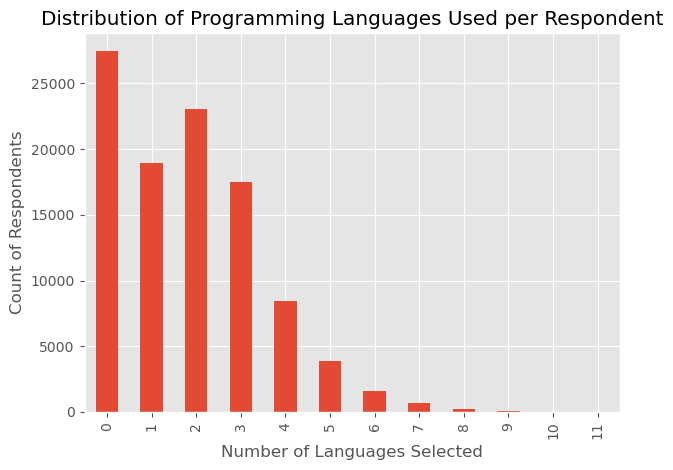

In [76]:
# Insight 5: Skill diversity per respondent 
lang_cols = [c for c in df.columns if c.startswith("Q7_Part_")]

# Count how many non-null language selections each respondent has
langs_per_person = df[lang_cols].notna().sum(axis=1)

# Summary stats
print("Languages per respondent (summary):")
print(langs_per_person.describe())

# Simple distribution view (top counts)
print("\nMost common number of languages selected:")
print(langs_per_person.value_counts().head(10))

# Plot distribution
langs_per_person.value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Programming Languages Used per Respondent")
plt.xlabel("Number of Languages Selected")
plt.ylabel("Count of Respondents")
plt.tight_layout()
plt.show()

Explanation: The summary statistics and distribution chart show the number of programming languages selected by each respondent. The dataset contains 101,845 respondents, with an average of approximately 1.84 languages per respondent. The median value is 2 languages, indicating that half of the respondents reported using two or fewer programming languages. The maximum observed value is 11 languages, though this occurs rarely. The frequency results show that the most common selections are 0 languages (27,440 respondents), 2 languages (23,056 respondents), and 1 language (18,951 respondents). The distribution decreases steadily as the number of languages increases, meaning fewer respondents report using many programming languages.Most respondents report using between one and three programming languages, suggesting that data science professionals typically rely on a small set of core tools rather than a large number of programming languages.